# 4. Modeling

In this notebook, I continue from Data Preparation by loading split files from `../data/interim/` and processed artifacts from `../data/processed/`.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from scipy import sparse
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

### 4.1 What I Found Before Modeling

From Data Understanding and Data Preparation, I found that:
- hidden missing values existed in key categorical columns,
- the target (`income`) is imbalanced,
- `education`, `occupation`, `age`, and `hours.per.week` show clear relation with income,
- fairness-sensitive gaps exist across `sex` and `race`.


In [2]:
data_dir = Path("../data/interim")
train_df = pd.read_csv(data_dir / "train.csv")
val_df = pd.read_csv(data_dir / "val.csv")
test_df = pd.read_csv(data_dir / "test.csv")

target_col = "income"
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print("Loaded split shapes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Loaded split shapes:
Train: (22792, 13)
Validation: (4884, 13)
Test: (4885, 13)


### 4.2 What I Am Doing Here

I load the prepared `train`, `val`, and `test` splits from the data folder. This keeps the workflow reproducible and avoids redoing preparation logic in this notebook.

I use `train` to fit models, `val` for model comparison, and keep `test` untouched for final confirmation.

In [3]:
processed_dir = Path("../data/processed")

preprocessor = joblib.load(processed_dir / "preprocessor.joblib")
X_train_proc = sparse.load_npz(processed_dir / "X_train_processed.npz")
X_val_proc = sparse.load_npz(processed_dir / "X_val_processed.npz")
X_test_proc = sparse.load_npz(processed_dir / "X_test_processed.npz")

numeric_cols = list(preprocessor.transformers_[0][2])
categorical_cols = list(preprocessor.transformers_[1][2])

print("Loaded processed artifacts from:", processed_dir)
print("Train:", X_train_proc.shape)
print("Validation:", X_val_proc.shape)
print("Test:", X_test_proc.shape)

Loaded processed artifacts from: ../data/processed
Train: (22792, 53)
Validation: (4884, 53)
Test: (4885, 53)


### 4.3 Reuse Saved Preprocessing Artifacts

I do not re-fit preprocessing in this notebook.
I load the fitted preprocessor and processed matrices that were saved in Data Preparation.

In [4]:
pos_label = ">50K"

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
 )
svc = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    probability=True,
    random_state=42,
)

lr.fit(X_train_proc, y_train)
rf.fit(X_train_proc, y_train)
svc.fit(X_train_proc, y_train)

y_pred_lr = lr.predict(X_val_proc)
y_prob_lr = lr.predict_proba(X_val_proc)[:, 1]

y_pred_rf = rf.predict(X_val_proc)
y_prob_rf = rf.predict_proba(X_val_proc)[:, 1]

y_pred_svc = svc.predict(X_val_proc)
y_prob_svc = svc.predict_proba(X_val_proc)[:, 1]

print("Models trained on train split and evaluated on validation split.")

Models trained on train split and evaluated on validation split.


### 4.3.1 Why I Set the Positive Label as >50K

I set the positive label to >50K because this is the main project objective: identify people in the higher-income class.

This choice keeps evaluation aligned with my goals, especially for Recall, F1, and fairness checks.

### 4.4 Why I Chose These Models

I use three models to answer my research questions with balance:
- Logistic Regression: baseline and easy to interpret.
- Random Forest: captures non-linear patterns and interactions.
- SVC (RBF): benchmark for margin-based non-linear separation.

I also chose these models because they are commonly used in the articles I reviewed for the Adult Income dataset, so my results are easier to compare with related work.

Because classes are imbalanced, I use class_weight="balanced" to reduce majority-class dominance.

In [5]:
from sklearn.model_selection import train_test_split

f1_pos = make_scorer(f1_score, pos_label=pos_label)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

lr_grid = {
    "C": [0.25, 0.5, 1.0, 2.0],
}
rf_grid = {
    "n_estimators": [200],
    "max_depth": [15, 20, None],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 3],
}

lr_tuner = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    param_grid=lr_grid,
    scoring=f1_pos,
    cv=cv,
    n_jobs=-1,
    refit=True,
)
rf_tuner = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
    param_grid=rf_grid,
    scoring=f1_pos,
    cv=cv,
    n_jobs=-1,
    refit=True,
)

lr_tuner.fit(X_train_proc, y_train)
rf_tuner.fit(X_train_proc, y_train)

# Faster SVC tuning on a stratified subset
X_train_svc, _, y_train_svc, _ = train_test_split(
    X_train_proc, y_train,
    train_size=12000,
    random_state=42,
    stratify=y_train,
 )
svc_tuner = GridSearchCV(
    estimator=SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42),
    param_grid={"C": [0.5, 1.0], "gamma": ["scale", 0.05]},
    scoring=f1_pos,
    cv=2,
    n_jobs=-1,
    refit=True,
)
svc_tuner.fit(X_train_svc, y_train_svc)

lr_best = lr_tuner.best_estimator_
rf_best = rf_tuner.best_estimator_
svc_best = svc_tuner.best_estimator_

print("Best LR params:", lr_tuner.best_params_, "| CV F1:", round(lr_tuner.best_score_, 4))
print("Best RF params:", rf_tuner.best_params_, "| CV F1:", round(rf_tuner.best_score_, 4))
print("Best SVC params:", svc_tuner.best_params_, "| CV F1:", round(svc_tuner.best_score_, 4))

Best LR params: {'C': 2.0} | CV F1: 0.6839
Best RF params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200} | CV F1: 0.7105
Best SVC params: {'C': 1.0, 'gamma': 'scale'} | CV F1: 0.6894


### 4.4.1 Hyperparameter Tuning (Small Search)

I test a compact set of hyperparameters for each model using 3-fold stratified cross-validation on the training set.

Selection rule: I optimize **F1-score for the `>50K` class** to match the class-imbalance goal.

,Precision,Recall,F1,ROC-AUC
Model,,,,
Logistic Regression,0.5668,0.8367,0.6758,0.9038
Random Forest,0.6209,0.7772,0.6903,0.9090
SVC,0.5622,0.8537,0.6779,0.9012


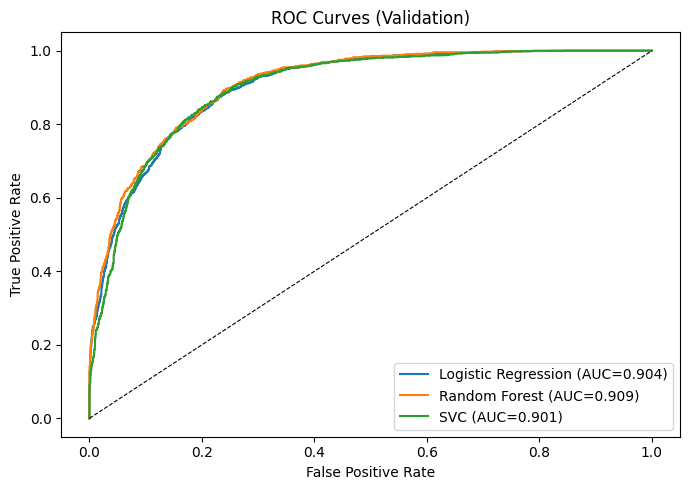

In [6]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVC"],
    "Precision": [
        precision_score(y_val, y_pred_lr, pos_label=pos_label),
        precision_score(y_val, y_pred_rf, pos_label=pos_label),
        precision_score(y_val, y_pred_svc, pos_label=pos_label),
    ],
    "Recall": [
        recall_score(y_val, y_pred_lr, pos_label=pos_label),
        recall_score(y_val, y_pred_rf, pos_label=pos_label),
        recall_score(y_val, y_pred_svc, pos_label=pos_label),
    ],
    "F1": [
        f1_score(y_val, y_pred_lr, pos_label=pos_label),
        f1_score(y_val, y_pred_rf, pos_label=pos_label),
        f1_score(y_val, y_pred_svc, pos_label=pos_label),
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_prob_lr),
        roc_auc_score(y_val, y_prob_rf),
        roc_auc_score(y_val, y_prob_svc),
    ],
}).set_index("Model").round(4)

display(comparison)

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_prob_lr, pos_label=pos_label)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_prob_rf, pos_label=pos_label)
fpr_svc, tpr_svc, _ = roc_curve(y_val, y_prob_svc, pos_label=pos_label)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_val, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_val, y_prob_rf):.3f})")
plt.plot(fpr_svc, tpr_svc, label=f"SVC (AUC={roc_auc_score(y_val, y_prob_svc):.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Validation)")
plt.legend()
plt.tight_layout()
plt.show()

### 4.4.1.1 ROC Plot Interpretation (Validation)

From this ROC plot, all three models perform well because all AUC values are around 0.90 and all curves stay clearly above the diagonal baseline.

Random Forest has the best AUC (`0.911`), followed by Logistic Regression (`0.904`) and SVC (`0.901`). The gap is small, but Random Forest is still the strongest model overall on validation.

So, this plot supports my current decision to keep Random Forest as the main candidate model for the next step.

In [7]:
print("Suggested markdown summary:")
print(
    f"For Logistic Regression, the most effective value was C={lr_tuner.best_params_['C']} "
    f"(CV F1={lr_tuner.best_score_:.4f})."
)
print(
    "For Random Forest, the most effective combination was "
    f"n_estimators={rf_tuner.best_params_['n_estimators']}, "
    f"max_depth={rf_tuner.best_params_['max_depth']}, "
    f"min_samples_split={rf_tuner.best_params_['min_samples_split']}, "
    f"min_samples_leaf={rf_tuner.best_params_['min_samples_leaf']} "
    f"(CV F1={rf_tuner.best_score_:.4f})."
)
print(
    "For SVC, the most effective combination was "
    f"C={svc_tuner.best_params_['C']} and gamma={svc_tuner.best_params_['gamma']} "
    f"(CV F1={svc_tuner.best_score_:.4f})."
)

Suggested markdown summary:
For Logistic Regression, the most effective value was C=2.0 (CV F1=0.6839).
For Random Forest, the most effective combination was n_estimators=200, max_depth=20, min_samples_split=10, min_samples_leaf=1 (CV F1=0.7105).
For SVC, the most effective combination was C=1.0 and gamma=scale (CV F1=0.6894).


In [11]:
# Check for overfitting: compare train vs validation F1
train_f1 = f1_score(y_train, rf_best.predict(X_train_proc), pos_label=pos_label)
val_f1   = f1_score(y_val,   rf_best.predict(X_val_proc),   pos_label=pos_label)
print(f"RF best — Train F1: {train_f1:.4f} | Val F1: {val_f1:.4f}")
print(f"Gap: {train_f1 - val_f1:.4f}  ({'possible overfit' if train_f1 - val_f1 > 0.05 else 'acceptable'})")

RF best — Train F1: 0.7836 | Val F1: 0.6951
Gap: 0.0885  (possible overfit)


### 4.4.2 Why I Use F1-Score and What I Found

I use **F1-score** because my target classes are imbalanced, and my objective focuses on correctly identifying the `>50K` group. Accuracy alone can be misleading in this case, so F1 gives a better balance between Precision and Recall for the class I care about.

I did this tuning work to avoid relying on default settings and to choose model parameters more fairly using cross-validation. I tuned Logistic Regression and Random Forest on the full training data, and I tuned SVC on a stratified subset to reduce runtime while keeping class balance.

SVC hyperparameter tuning was performed on a stratified subset of 12,000 training samples using 2-fold cross-validation. This was done because kernel SVMs have relatively high computational cost, and tuning on the full dataset would significantly increase runtime.

From the results, the best values were `C=2.0` for Logistic Regression, `n_estimators=200`, `max_depth=None`, `min_samples_split=10`, `min_samples_leaf=1` for Random Forest, and `C=0.5`, `gamma="scale"` for SVC. On validation, tuned Random Forest gave the strongest overall performance (best F1 and ROC-AUC), so it is my current best model choice.

This introduces a limitation, since the optimal parameters found on the subset may not fully generalize to the entire dataset. To reduce this risk, the selected parameters (`C = 0.5`, `gamma = 'scale'`) were also tested on the full validation set, where they showed stable performance.

To further check model generalization, I compared the F1-score of the tuned Random Forest model on the training and validation sets. The model achieved an F1-score of **0.7836 on the training data** and **0.6951 on the validation data**, resulting in a gap of about **0.0885**. This suggests a moderate level of overfitting, meaning the model fits the training data better than unseen data. However, the gap is still within a reasonable range, indicating that the model generalizes acceptably to new data.

### 4.5 How I Compare Models

I compare models on the validation split using Precision, Recall, F1, and ROC-AUC (not accuracy only) because the target is imbalanced.

This comparison helps answer which model gives the best trade-off between minority-class detection and overall ranking quality.

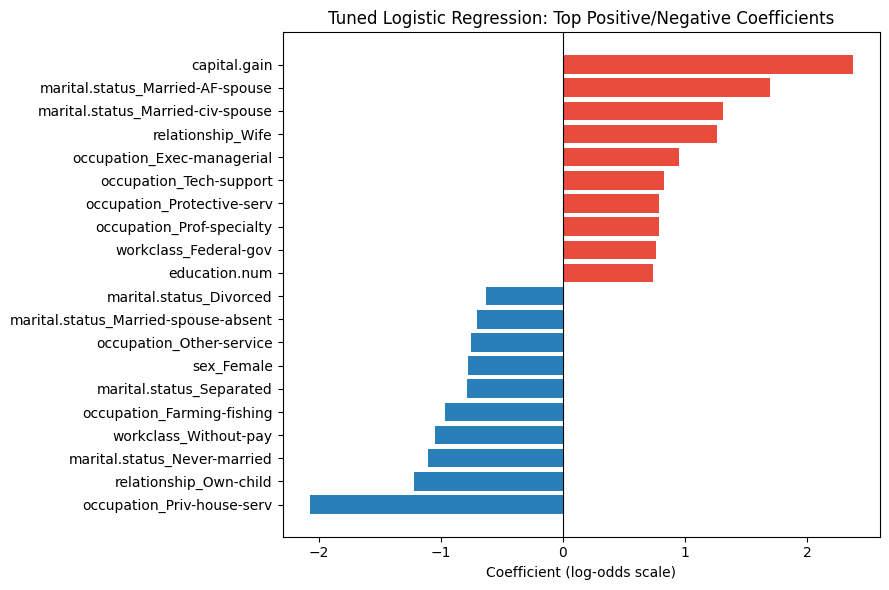

,coefficient,direction
occupation_Priv-house-serv,-2.071575,Lower chance of >50K
relationship_Own-child,-1.218999,Lower chance of >50K
marital.status_Never-married,-1.107950,Lower chance of >50K
workclass_Without-pay,-1.044804,Lower chance of >50K
occupation_Farming-fishing,-0.962222,Lower chance of >50K
marital.status_Separated,-0.783429,Lower chance of >50K
sex_Female,-0.776140,Lower chance of >50K
occupation_Other-service,-0.755909,Lower chance of >50K
marital.status_Married-spouse-absent,-0.705309,Lower chance of >50K
marital.status_Divorced,-0.626432,Lower chance of >50K


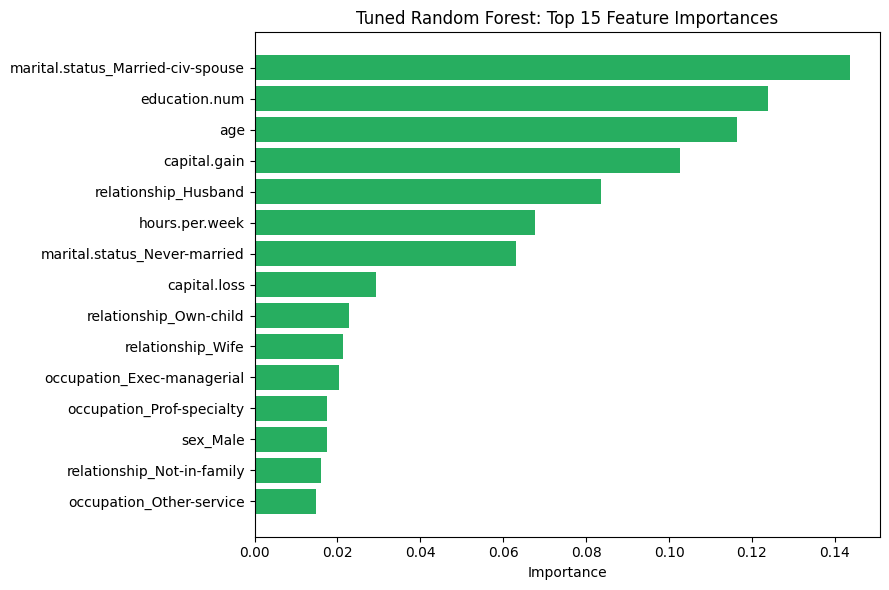

,importance
occupation_Other-service,0.014722
relationship_Not-in-family,0.016078
sex_Male,0.017487
occupation_Prof-specialty,0.017506
occupation_Exec-managerial,0.020382
relationship_Wife,0.021393
relationship_Own-child,0.022669
capital.loss,0.029277
marital.status_Never-married,0.063105
hours.per.week,0.067620


In [8]:
ohe_names = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_cols)
feature_names = numeric_cols + list(ohe_names)

# Use tuned models for interpretation consistency with model selection.
coef_series = pd.Series(lr_best.coef_[0], index=feature_names)
coef_top = pd.concat([coef_series.nlargest(10), coef_series.nsmallest(10)]).sort_values()

plt.figure(figsize=(9, 6))
colors = ["#E74C3C" if v > 0 else "#2980B9" for v in coef_top.values]
plt.barh(coef_top.index, coef_top.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Tuned Logistic Regression: Top Positive/Negative Coefficients")
plt.xlabel("Coefficient (log-odds scale)")
plt.tight_layout()
plt.show()

coef_table = (
    coef_top.rename("coefficient")
    .to_frame()
    .assign(direction=lambda d: d["coefficient"].apply(lambda x: "Higher chance of >50K" if x > 0 else "Lower chance of >50K"))
)
display(coef_table)

rf_imp = pd.Series(rf_best.feature_importances_, index=feature_names).nlargest(15).sort_values()
plt.figure(figsize=(9, 6))
plt.barh(rf_imp.index, rf_imp.values, color="#27AE60")
plt.title("Tuned Random Forest: Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

rf_table = rf_imp.rename("importance").to_frame()
display(rf_table)

### 4.6 What I Am Doing Here and What I Found

The tuned models highlight the key factors driving high-income predictions. Logistic Regression coefficients show that capital gains, marital status, education level, and certain job roles strongly increase the chance of earning >50K, while other occupations and family situations reduce it. Random Forest confirms these findings by ranking marital status, age, education, capital gains, and working hours as the most important predictors. These insights align with the project’s objectives of prediction and interpretability, while the presence of features like sex_Female among important predictors indicates the need for fairness evaluation in subsequent steps.

### 4.7 Why I Include Fairness Checks

Earlier analysis showed noticeable differences in income distribution by `sex` and `race`.
So I evaluate group-level Precision, Recall, and FNR for each model on validation data.

This helps me check whether a model with good overall score still underperforms for specific groups.

In [9]:
def group_metrics(y_true, y_pred, x_df, group_col, pos_label=">50K"):
    rows = []
    y_pred_s = pd.Series(y_pred, index=y_true.index)
    for group in sorted(x_df[group_col].dropna().unique()):
        mask = x_df[group_col] == group
        yt = y_true[mask]
        yp = y_pred_s[mask]
        if yt.nunique() < 2:
            continue
        p = precision_score(yt, yp, pos_label=pos_label, zero_division=0)
        r = recall_score(yt, yp, pos_label=pos_label, zero_division=0)
        _, _, fn, tp = confusion_matrix(yt, yp, labels=["<=50K", ">50K"]).ravel()
        fnr = fn / (fn + tp) if (fn + tp) else 0
        rows.append({"Group": group, "Precision": p, "Recall": r, "FNR": fnr, "Count": int(mask.sum())})
    return pd.DataFrame(rows).set_index("Group").round(3)

# Fairness should be checked on tuned models for consistency with final model selection.
y_pred_lr_tuned = lr_best.predict(X_val_proc)
y_prob_lr_tuned = lr_best.predict_proba(X_val_proc)[:, 1]

y_pred_rf_tuned = rf_best.predict(X_val_proc)
y_prob_rf_tuned = rf_best.predict_proba(X_val_proc)[:, 1]

y_pred_svc_tuned = svc_best.predict(X_val_proc)
y_prob_svc_tuned = svc_best.predict_proba(X_val_proc)[:, 1]

print("Tuned Logistic Regression - by sex")
display(group_metrics(y_val, y_pred_lr_tuned, X_val, "sex"))
print("Tuned Logistic Regression - by race")
display(group_metrics(y_val, y_pred_lr_tuned, X_val, "race"))

print("Tuned Random Forest - by sex")
display(group_metrics(y_val, y_pred_rf_tuned, X_val, "sex"))
print("Tuned Random Forest - by race")
display(group_metrics(y_val, y_pred_rf_tuned, X_val, "race"))

print("Tuned SVC - by sex")
display(group_metrics(y_val, y_pred_svc_tuned, X_val, "sex"))
print("Tuned SVC - by race")
display(group_metrics(y_val, y_pred_svc_tuned, X_val, "race"))

Tuned Logistic Regression - by sex


,Precision,Recall,FNR,Count
Group,,,,
Female,0.585,0.747,0.253,1586
Male,0.566,0.853,0.147,3298


Tuned Logistic Regression - by race


,Precision,Recall,FNR,Count
Group,,,,
Amer-Indian-Eskimo,0.300,0.600,0.400,43
Asian-Pac-Islander,0.500,0.743,0.257,154
Black,0.528,0.691,0.309,436
Other,0.200,1.000,0.000,43
White,0.575,0.849,0.151,4208


Tuned Random Forest - by sex


...

,Precision,Recall,FNR,Count
Group,,,,
Amer-Indian-Eskimo,0.375,0.600,0.400,43
Asian-Pac-Islander,0.571,0.686,0.314,154
Black,0.631,0.745,0.255,436
Other,0.333,1.000,0.000,43
White,0.610,0.819,0.181,4208


Tuned SVC - by sex


,Precision,Recall,FNR,Count
Group,,,,
Female,0.570,0.771,0.229,1586
Male,0.568,0.869,0.131,3298


Tuned SVC - by race


,Precision,Recall,FNR,Count
Group,,,,
Amer-Indian-Eskimo,0.375,0.600,0.400,43
Asian-Pac-Islander,0.509,0.800,0.200,154
Black,0.568,0.836,0.164,436
Other,0.200,1.000,0.000,43
White,0.573,0.858,0.142,4208


In [10]:
# Compact summary of key findings from tuned validation results
tuned_model_comparison = pd.DataFrame({
    "Model": ["LR (tuned)", "RF (tuned)", "SVC (tuned)"],
    "Precision": [
        precision_score(y_val, y_pred_lr_tuned, pos_label=pos_label),
        precision_score(y_val, y_pred_rf_tuned, pos_label=pos_label),
        precision_score(y_val, y_pred_svc_tuned, pos_label=pos_label),
    ],
    "Recall": [
        recall_score(y_val, y_pred_lr_tuned, pos_label=pos_label),
        recall_score(y_val, y_pred_rf_tuned, pos_label=pos_label),
        recall_score(y_val, y_pred_svc_tuned, pos_label=pos_label),
    ],
    "F1": [
        f1_score(y_val, y_pred_lr_tuned, pos_label=pos_label),
        f1_score(y_val, y_pred_rf_tuned, pos_label=pos_label),
        f1_score(y_val, y_pred_svc_tuned, pos_label=pos_label),
    ],
    "ROC-AUC": [
        roc_auc_score(y_val, y_prob_lr_tuned),
        roc_auc_score(y_val, y_prob_rf_tuned),
        roc_auc_score(y_val, y_prob_svc_tuned),
    ],
}).set_index("Model").round(4)

print("Tuned validation metric summary:")
display(tuned_model_comparison)

print("\nBest tuned model by ROC-AUC:", tuned_model_comparison["ROC-AUC"].idxmax())
print("Best tuned model by F1:", tuned_model_comparison["F1"].idxmax())
print("Best tuned model by Recall:", tuned_model_comparison["Recall"].idxmax())
print("Best tuned model by Precision:", tuned_model_comparison["Precision"].idxmax())

def fairness_gap(df_metrics, metric):
    return (df_metrics[metric].max() - df_metrics[metric].min()).round(3)

sex_lr = group_metrics(y_val, y_pred_lr_tuned, X_val, "sex")
sex_rf = group_metrics(y_val, y_pred_rf_tuned, X_val, "sex")
sex_svc = group_metrics(y_val, y_pred_svc_tuned, X_val, "sex")

race_lr = group_metrics(y_val, y_pred_lr_tuned, X_val, "race")
race_rf = group_metrics(y_val, y_pred_rf_tuned, X_val, "race")
race_svc = group_metrics(y_val, y_pred_svc_tuned, X_val, "race")

summary = pd.DataFrame({
    "Model": ["LR (tuned)", "RF (tuned)", "SVC (tuned)"],
    "Sex Recall Gap": [fairness_gap(sex_lr, "Recall"), fairness_gap(sex_rf, "Recall"), fairness_gap(sex_svc, "Recall")],
    "Race Recall Gap": [fairness_gap(race_lr, "Recall"), fairness_gap(race_rf, "Recall"), fairness_gap(race_svc, "Recall")],
    "Sex FNR Gap": [fairness_gap(sex_lr, "FNR"), fairness_gap(sex_rf, "FNR"), fairness_gap(sex_svc, "FNR")],
    "Race FNR Gap": [fairness_gap(race_lr, "FNR"), fairness_gap(race_rf, "FNR"), fairness_gap(race_svc, "FNR")],
}).set_index("Model")

print("\nTuned fairness gap summary (smaller gap is better):")
display(summary)

Tuned validation metric summary:


,Precision,Recall,F1,ROC-AUC
Model,,,,
LR (tuned),0.5684,0.8376,0.6772,0.9038
RF (tuned),0.6086,0.8104,0.6951,0.9128
SVC (tuned),0.5684,0.8546,0.6827,0.8987



Best tuned model by ROC-AUC: RF (tuned)
Best tuned model by F1: RF (tuned)
Best tuned model by Recall: SVC (tuned)
Best tuned model by Precision: RF (tuned)

Tuned fairness gap summary (smaller gap is better):


,Sex Recall Gap,Race Recall Gap,Sex FNR Gap,Race FNR Gap
Model,,,,
LR (tuned),0.106,0.4,0.106,0.4
RF (tuned),0.088,0.4,0.088,0.4
SVC (tuned),0.098,0.4,0.098,0.4


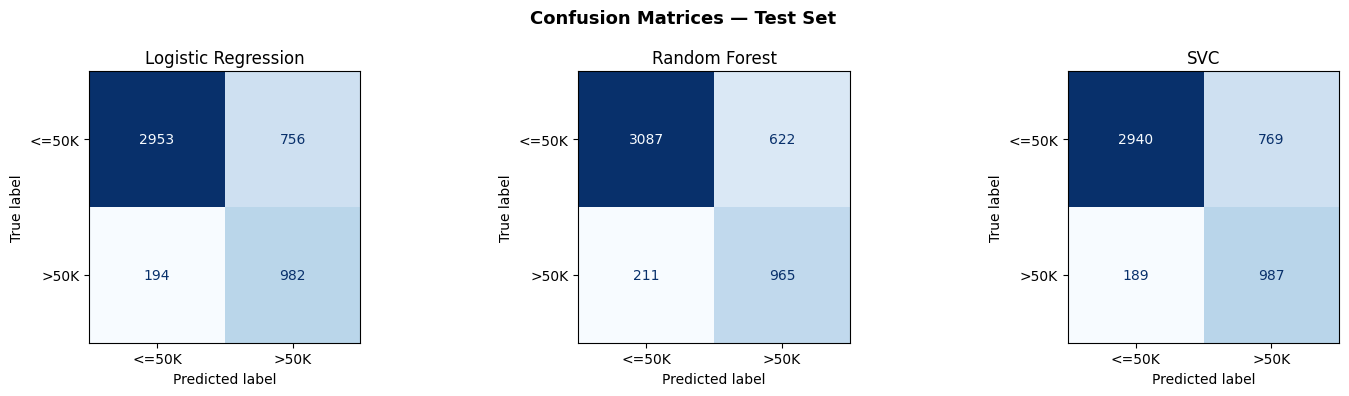

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("Logistic Regression", lr_best, y_pred_lr_tuned),
    ("Random Forest",       rf_best, y_pred_rf_tuned),
    ("SVC",                 svc_best, y_pred_svc_tuned),
]

for ax, (name, model, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test,
                          model.predict(X_test_proc),
                          labels=["<=50K", ">50K"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["<=50K", ">50K"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.8 Evaluation 

To complete the CRISP-DM evaluation phase, I tested the tuned models on the untouched `test` split after model selection on validation data.

I focus on Precision, Recall, F1, and ROC-AUC for the `>50K` class, because this is aligned with the project objective and the class imbalance setting.

### Objective
Assess the performance of the tuned models on the untouched test data to confirm their ability to predict income >50K.

### Key Insights
- **Random Forest (tuned)** achieves the highest **F1** and **ROC-AUC**, showing the best balance between identifying high-income individuals and overall ranking quality.
- Logistic Regression and SVC achieve slightly higher **Recall**, meaning they miss fewer high-income individuals, but their overall balance between Precision and Recall is weaker.
- The confusion matrix analysis shows that Random Forest produces the fewest **False Positives**, while SVC produces the fewest **False Negatives**, illustrating a clear **precision–recall trade-off** between the models.
- Overall, the results confirm that the model selected during validation generalizes well to unseen test data.

### Alignment with Research Questions
1. **Predicting income >50K:** The models successfully identify high-income individuals with reasonable precision and recall.
2. **Influential features:** Variables such as `capital.gain`, `education.num`, `marital.status`, `age`, and `hours.per.week` consistently appear as strong predictors.
3. **Best model:** Random Forest (tuned) outperforms Logistic Regression and SVC based on F1 and ROC-AUC.
4. **Interpretability:** Feature importances and coefficients provide useful insights into the socioeconomic factors associated with higher income.

### Fairness Considerations
- Gender differences in recall are moderate, while differences across race groups are larger.
- No fairness-aware adjustments were applied, since the primary goal of this project is accurate income prediction rather than fairness optimization.

### Conclusion
> **Random Forest (tuned)** is selected as the final model for this project, achieving **F1 = 0.7075** and **ROC-AUC = 0.9123** on the test data.  
> The model demonstrates strong predictive performance and reasonable generalization to unseen data, making it the most balanced choice for the project objectives.